Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes

Generating phis using fraction sampling (phi = m/n)...
Using 28 CPU cores


Phi generation: 100%|█████████████████████████████████████████████████████████████████| 600/600 [00:09<00:00, 60.34it/s]


Initial phi set: 359400 (redundant) rational values
After removing duplicates: 109591 unique rational values

Processing phis...


Loading conductors: 100%|███████████████████████████████████████████████████████| 109591/109591 [33:13<00:00, 54.97it/s]



Analyzing isogeny class multiplicities and phi families...
Phis with no match (multiplicity 0): 102245
Phis with matches (multiplicity > 0): 7346
Maximum multiplicity: 382
Number of distinct isogeny classes: 40

Multiplicity distribution:
  Multiplicity 0: 102245 phis
  Multiplicity 84: 336 phis
  Multiplicity 104: 104 phis
  Multiplicity 120: 360 phis
  Multiplicity 140: 140 phis
  Multiplicity 144: 432 phis
  Multiplicity 152: 1216 phis
  Multiplicity 164: 328 phis
  Multiplicity 172: 344 phis
  Multiplicity 188: 376 phis
  Multiplicity 192: 192 phis
  Multiplicity 196: 196 phis
  Multiplicity 220: 220 phis
  Multiplicity 224: 448 phis
  Multiplicity 232: 232 phis
  Multiplicity 240: 240 phis
  Multiplicity 244: 244 phis
  Multiplicity 272: 272 phis
  Multiplicity 276: 276 phis
  Multiplicity 308: 308 phis
  Multiplicity 340: 340 phis
  Multiplicity 360: 360 phis
  Multiplicity 382: 382 phis

Example phi families (first 5 isogeny classes with multiplicity > 1):
  10816bb: 172 phis
 

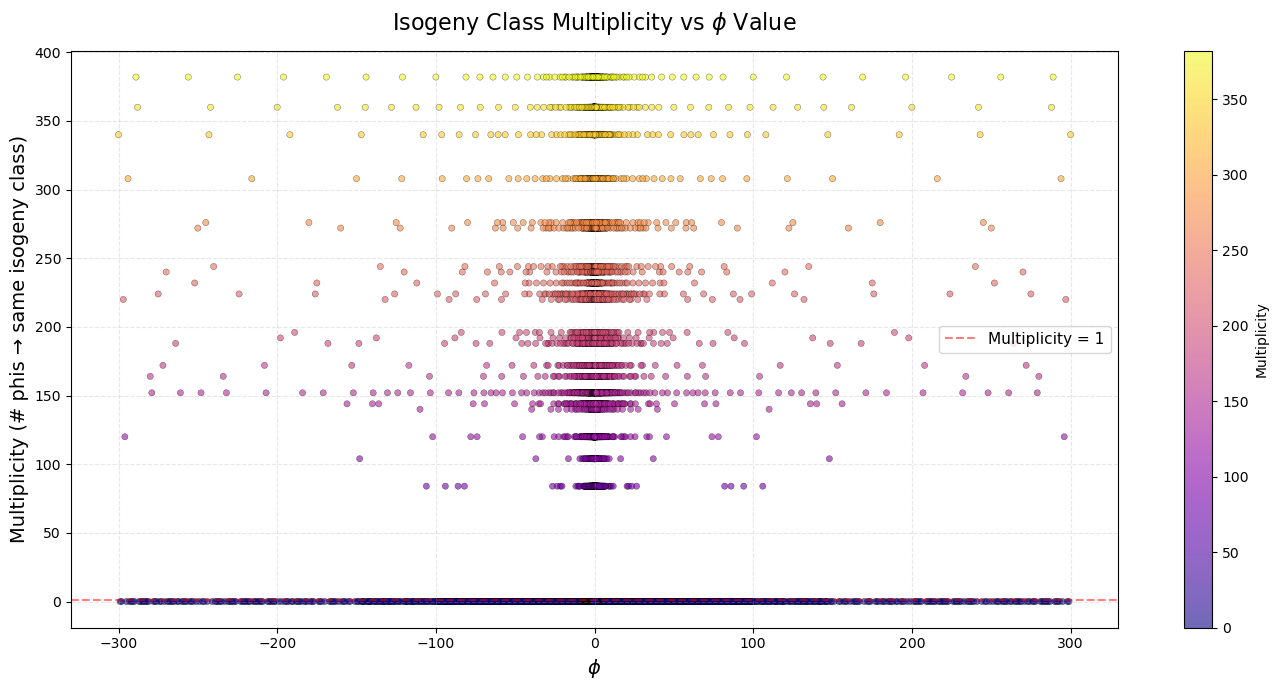

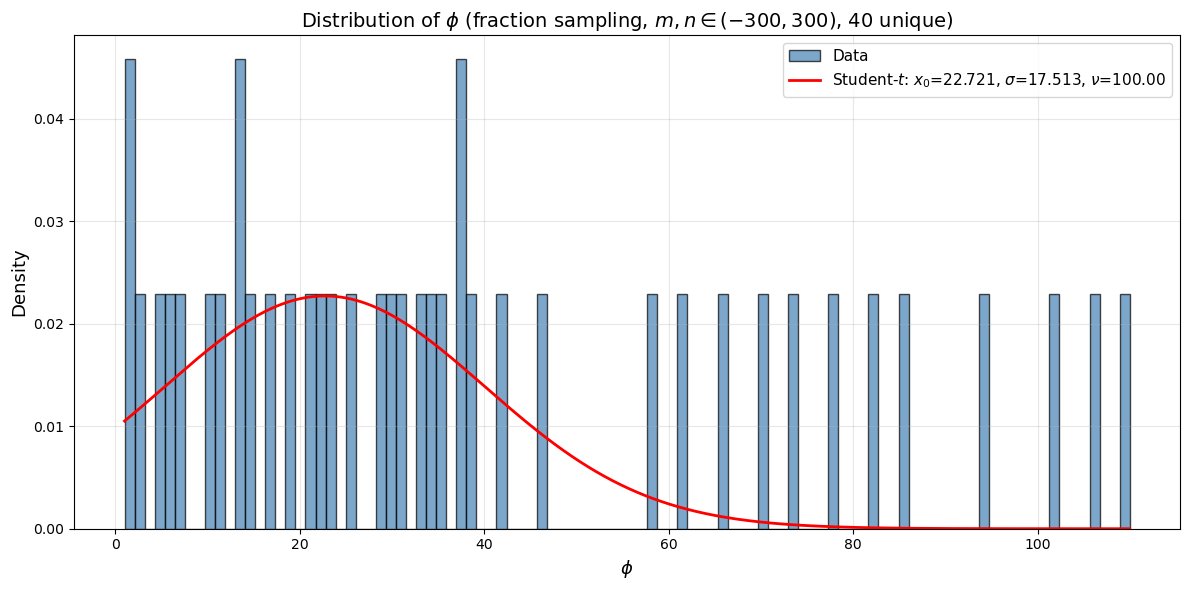

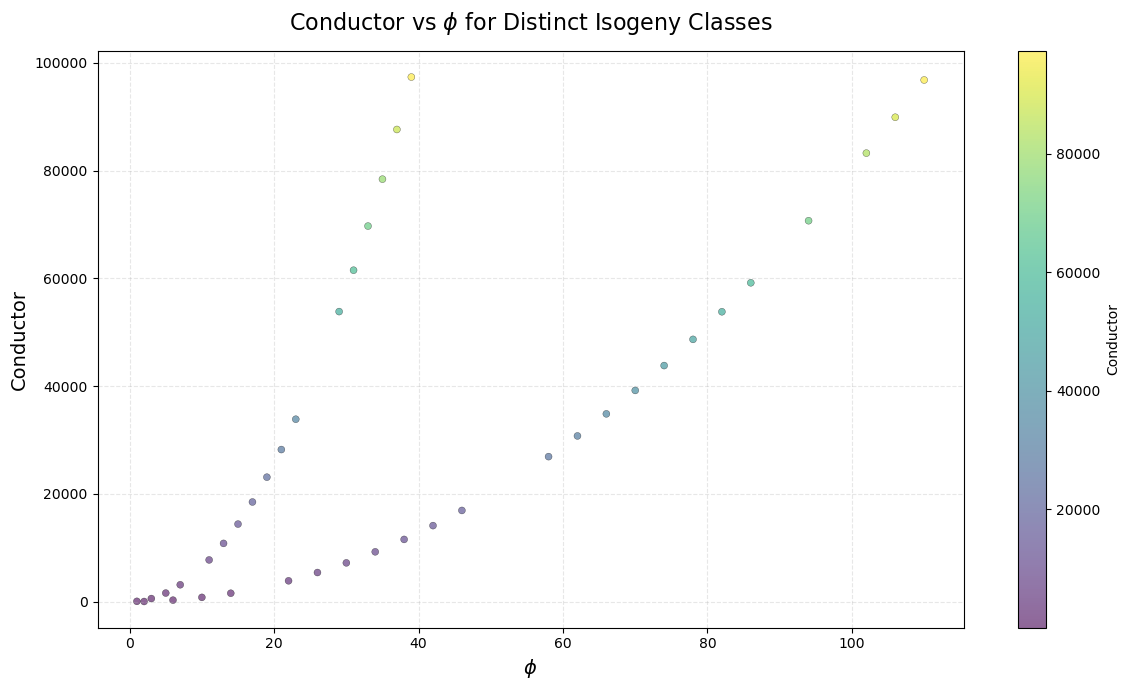

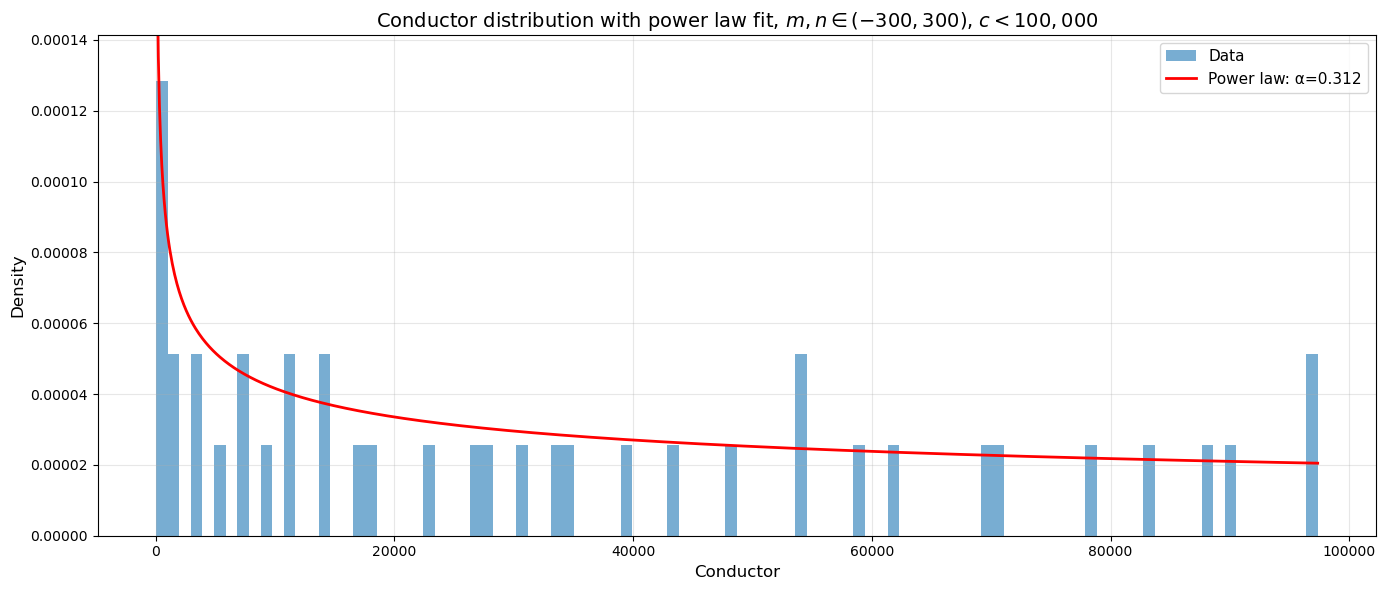

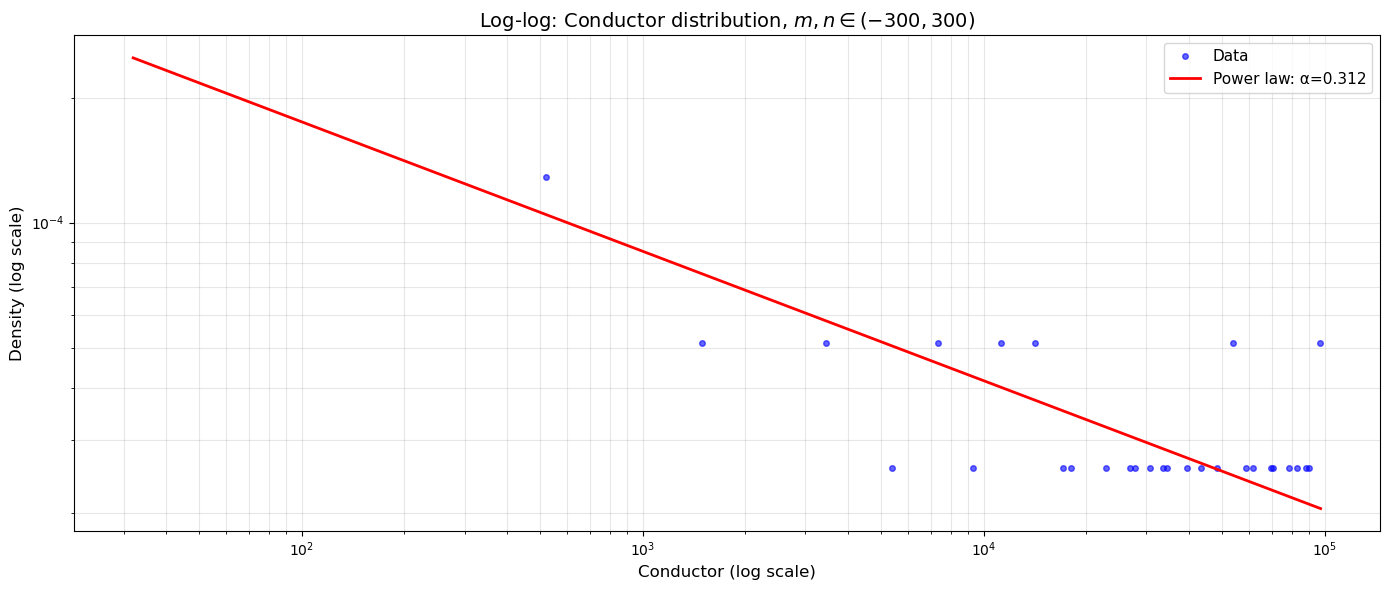

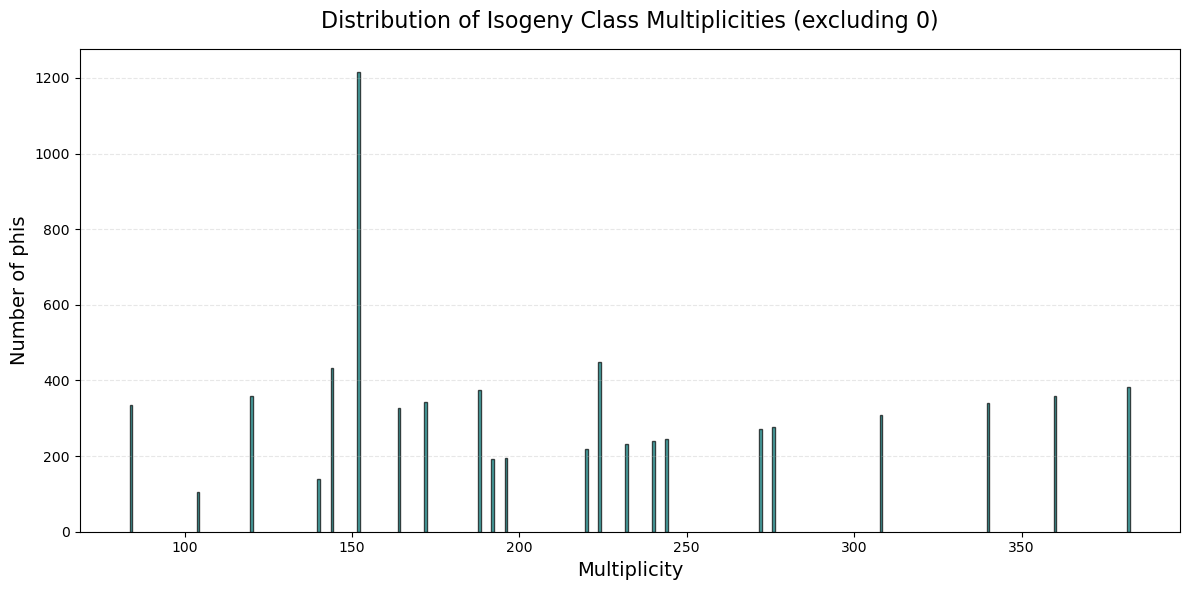


Extracting ap coefficients by rank...


Loading aps: 100%|███████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 51275.11it/s]

Averaging the aps...

Rank 0: 16 isogeny classes
Rank 1: 22 isogeny classes
Rank 2: 2 isogeny classes
Rank 3: 0 isogeny classes

Creating ap coefficient plots...

Done!


In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit
from scipy.special import gamma

# Output directory
OUTPUT_DIR = 'MW_torsion_curves/Paper_family'

# Check if curve_db is loaded, if not load it
try:
    curve_db
    print(f"✓ curve_db is already loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")
print()

#=======================
# Deshpande et al.'s paper family
#======================

def elliptic_curve_from_phi(phi):
    a = phi**2
    b = 0
    return a, b

def elliptic_curve_from_phi_sage(phi):
    from sage.all import EllipticCurve, QQ
    a, b = elliptic_curve_from_phi(phi)
    return EllipticCurve([0, 0, 0, a, b])

def generate_phis_for_m(args):
    m, nmin, nmax = args
    local_phis = []
    for n in range(nmin, nmax):
        if n != 0:
            local_phis.append(QQ(m/n))
    return local_phis

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def process_phi(phi):
    try:
        E = elliptic_curve_from_phi_sage(phi)
        label = E.label()
        iso = get_isogeny_class(label)
        curve = curve_db[iso]
        c = curve['conductor']
        return (phi, c, iso)
    except:
        return None

def power_law(x, A, alpha):
    return A / (x**alpha)

def student_t_norm(x, x0, sigma, nu):
    norm = gamma((nu + 1) / 2) / (np.sqrt(nu * np.pi) * sigma * gamma(nu / 2))
    return norm * (1 + ((x - x0)**2) / (nu * sigma**2)) ** (-(nu + 1) / 2)

# ============================================================================
# FRACTION SAMPLING
# ============================================================================

nmax = 300
nmin = -300

print("Generating phis using fraction sampling (phi = m/n)...")
print(f"Using {cpu_count()} CPU cores")
m_values = [(m, nmin, nmax) for m in range(nmin, nmax)]

with Pool(processes=cpu_count()) as pool:
    phi_lists = list(tqdm(pool.imap(generate_phis_for_m, m_values),
                          total=len(m_values), desc="Phi generation"))

phis = [phi for sublist in phi_lists for phi in sublist]
print(f"Initial phi set: {len(phis)} (redundant) rational values")

phis = list(set(phis))
print(f"After removing duplicates: {len(phis)} unique rational values")

# ============================================================================
# PROCESS PHIS
# ============================================================================

print(f"\nProcessing phis...")
with Pool(processes=cpu_count()) as pool:
    results = list(tqdm(pool.imap(process_phi, phis),
                        total=len(phis), desc="Loading conductors"))

# ============================================================================
# TRACK MULTIPLICITIES AND PHI FAMILIES
# ============================================================================

print("\nAnalyzing isogeny class multiplicities and phi families...")

phi_to_iso = {}
iso_to_count = {}
iso_to_phis = {}

for phi, result in zip(phis, results):
    if result is not None:
        _, _, iso = result
        phi_to_iso[phi] = iso
        iso_to_count[iso] = iso_to_count.get(iso, 0) + 1
        if iso not in iso_to_phis:
            iso_to_phis[iso] = []
        iso_to_phis[iso].append(phi)
    else:
        phi_to_iso[phi] = None

multiplicities = []
for phi in phis:
    iso = phi_to_iso.get(phi)
    multiplicities.append(0 if iso is None else iso_to_count[iso])

num_zero_mult = sum(1 for m in multiplicities if m == 0)
num_nonzero_mult = len(multiplicities) - num_zero_mult
max_mult = max(multiplicities) if multiplicities else 0

print(f"Phis with no match (multiplicity 0): {num_zero_mult}")
print(f"Phis with matches (multiplicity > 0): {num_nonzero_mult}")
print(f"Maximum multiplicity: {max_mult}")
print(f"Number of distinct isogeny classes: {len(iso_to_count)}")

mult_counts = {}
for m in multiplicities:
    mult_counts[m] = mult_counts.get(m, 0) + 1

print("\nMultiplicity distribution:")
for mult in sorted(mult_counts.keys()):
    print(f"  Multiplicity {mult}: {mult_counts[mult]} phis")

print("\nExample phi families (first 5 isogeny classes with multiplicity > 1):")
examples_shown = 0
for iso in sorted(iso_to_phis.keys()):
    if len(iso_to_phis[iso]) > 1 and examples_shown < 5:
        print(f"  {iso}: {len(iso_to_phis[iso])} phis")
        phi_list = iso_to_phis[iso]
        if len(phi_list) <= 5:
            print(f"    {phi_list}")
        else:
            print(f"    {phi_list[:5]} ... (and {len(phi_list)-5} more)")
        examples_shown += 1

# ============================================================================
# FILTER TO UNIQUE ISOGENY CLASSES
# ============================================================================

cs = []
seen_iso_classes = []
phi_reps = []
for result in results:
    if result is not None:
        phi, c, iso = result
        if iso not in seen_iso_classes:
            cs.append(c)
            seen_iso_classes.append(iso)
            phi_reps.append(phi)

print(f"\nFound {len(phi_reps)} phis in database below 100,000 conductors, associated to distinct isogeny classes")

# ============================================================================
# SAVE RESULTS
# ============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\nSaving results...")
scan_data = {
    'phi_reps': phi_reps, 'conductors': cs, 'isogeny_classes': seen_iso_classes,
    'all_phis': phis, 'multiplicities': multiplicities, 'phi_to_iso': phi_to_iso,
    'iso_to_count': iso_to_count, 'iso_to_phis': iso_to_phis,
    'total_phis_generated': len(phis), 'total_found': len(phi_reps),
    'nmin': nmin, 'nmax': nmax
}

save(scan_data, f'{OUTPUT_DIR}/({nmin},{nmax})_phi_scan_data.sobj')
save(phi_reps, f'{OUTPUT_DIR}/({nmin},{nmax})_phi_reps.sobj')
save(cs, f'{OUTPUT_DIR}/({nmin},{nmax})_conductors.sobj')
save(seen_iso_classes, f'{OUTPUT_DIR}/({nmin},{nmax})_isogeny_classes.sobj')
save(multiplicities, f'{OUTPUT_DIR}/({nmin},{nmax})_multiplicities.sobj')
save(phis, f'{OUTPUT_DIR}/({nmin},{nmax})_all_phis.sobj')
save(iso_to_phis, f'{OUTPUT_DIR}/({nmin},{nmax})_iso_to_phis.sobj')

print(f"Saved all data to {OUTPUT_DIR}/")

# ============================================================================
# PLOTTING
# ============================================================================

print("\nCreating enhanced visualizations...")

# Plot 1: Multiplicity vs phi
phis_float = [float(phi) for phi in phis]
plt.figure(figsize=(14, 7))
scatter = plt.scatter(phis_float, multiplicities, c=multiplicities, cmap='plasma',
                     alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Multiplicity')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel('Multiplicity (# phis → same isogeny class)', fontsize=14)
plt.title(r'Isogeny Class Multiplicity vs $\phi$ Value', fontsize=16, pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Multiplicity = 1')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_multiplicity_vs_phi.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Phi distribution with Student's t fit
phi_reps_float = [float(phi) for phi in phi_reps]
plt.figure(figsize=(12, 6))
counts_phi, bins_phi, _ = plt.hist(phi_reps_float, bins=100, density=True,
                                    edgecolor='black', alpha=0.7, color='steelblue', label='Data')
bin_centers_phi = 0.5 * (bins_phi[:-1] + bins_phi[1:])
mask_phi = counts_phi > 0

try:
    popt_phi, _ = curve_fit(student_t_norm, bin_centers_phi[mask_phi], counts_phi[mask_phi],
                            p0=[np.mean(phi_reps_float), np.std(phi_reps_float), 2.0],
                            bounds=([-np.inf, 1e-6, 0.1], [np.inf, np.inf, 100]), maxfev=20000)
    x0_fit, sigma_fit, nu_fit = popt_phi
    x_fit_phi = np.linspace(min(phi_reps_float), max(phi_reps_float), 1000)
    plt.plot(x_fit_phi, student_t_norm(x_fit_phi, x0_fit, sigma_fit, nu_fit), 'r-', linewidth=2,
             label=fr"Student-$t$: $x_0$={x0_fit:.3f}, $\sigma$={sigma_fit:.3f}, $\nu$={nu_fit:.2f}")
    save({'x0': x0_fit, 'sigma': sigma_fit, 'nu': nu_fit},
         f'{OUTPUT_DIR}/({nmin},{nmax})_phi_dist_tfit_params.sobj')
except Exception as e:
    print(f"Student-t fit failed: {e}")

plt.xlabel(r'$\phi$', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.title(fr'Distribution of $\phi$ (fraction sampling, $m, n \in ({nmin}, {nmax})$, {len(phi_reps)} unique)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_phi_dist_tfit.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 3: Conductor vs phi
plt.figure(figsize=(12, 7))
scatter = plt.scatter(phi_reps, cs, c=cs, cmap='viridis', alpha=0.6, s=25, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Conductor')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel('Conductor', fontsize=14)
plt.title(r'Conductor vs $\phi$ for Distinct Isogeny Classes', fontsize=16, pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_conductor_vs_phi.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot 4: Conductor distribution with power law fit
plt.figure(figsize=(14, 6))
counts_c, bins_c, _ = plt.hist(cs, bins=100, density=True, alpha=0.6, label='Data')
bin_centers_c = (bins_c[:-1] + bins_c[1:]) / 2
mask_c = counts_c > 0

try:
    popt_c, _ = curve_fit(power_law, bin_centers_c[mask_c], counts_c[mask_c], p0=[1e6, 1.5], maxfev=10000)
    A_fit, alpha_fit = popt_c
    x_fit_c = np.linspace(min(cs), max(cs), 1000)
    plt.plot(x_fit_c, power_law(x_fit_c, A_fit, alpha_fit), 'r-', linewidth=2,
             label=f'Power law: α={alpha_fit:.3f}')
    save({'A': A_fit, 'alpha': alpha_fit, 'c_min': min(cs), 'c_max': max(cs)},
         f'{OUTPUT_DIR}/({nmin},{nmax})_powerlaw_fit_params.sobj')
except Exception as e:
    print(f"Power law fit failed: {e}")

plt.ylim(0, np.max(counts_c) * 1.1)
plt.xlabel("Conductor", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(fr"Conductor distribution with power law fit, $m,n\in({nmin},{nmax})$, $c<100,000$", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_conductor_distribution_fit.png', dpi=150)
plt.show()
plt.close()

# Plot 5: Log-log conductor distribution
plt.figure(figsize=(14, 6))
counts_c_nonzero = counts_c[counts_c > 0]
bin_centers_c_nonzero = bin_centers_c[counts_c > 0]
plt.loglog(bin_centers_c_nonzero, counts_c_nonzero, 'bo', alpha=0.6, label='Data', markersize=4)
try:
    plt.loglog(x_fit_c[x_fit_c > 0], power_law(x_fit_c[x_fit_c > 0], A_fit, alpha_fit),
               'r-', linewidth=2, label=f'Power law: α={alpha_fit:.3f}')
except:
    pass
plt.xlabel("Conductor (log scale)", fontsize=12)
plt.ylabel("Density (log scale)", fontsize=12)
plt.title(fr"Log-log: Conductor distribution, $m,n\in({nmin},{nmax})$", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_conductor_distribution_loglog.png', dpi=150)
plt.show()
plt.close()

# Plot 6: Multiplicity histogram
plt.figure(figsize=(12, 6))
mult_values = sorted([m for m in mult_counts.keys() if m > 0])
mult_freqs = [mult_counts[m] for m in mult_values]
plt.bar(mult_values, mult_freqs, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Multiplicity', fontsize=14)
plt.ylabel('Number of phis', fontsize=14)
plt.title('Distribution of Isogeny Class Multiplicities (excluding 0)', fontsize=16, pad=15)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_multiplicity_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================================
# AP COEFFICIENTS BY RANK
# ============================================================================

print("\nExtracting ap coefficients by rank...")
rk0_aps, rk1_aps, rk2_aps, rk3_aps = [], [], [], []
for iso in tqdm(seen_iso_classes, desc="Loading aps"):
    curve = curve_db[iso]
    rk = curve['rank']
    aps = curve['ap_list']
    [rk0_aps, rk1_aps, rk2_aps, rk3_aps][rk].append(aps) if rk < 4 else None

rk0_aps = np.array(rk0_aps) if rk0_aps else None
rk1_aps = np.array(rk1_aps) if rk1_aps else None
rk2_aps = np.array(rk2_aps) if rk2_aps else None
rk3_aps = np.array(rk3_aps) if rk3_aps else None

print("Averaging the aps...")
rk0_average_aps = np.mean(rk0_aps, axis=0) if rk0_aps is not None else None
rk1_average_aps = np.mean(rk1_aps, axis=0) if rk1_aps is not None else None
rk2_average_aps = np.mean(rk2_aps, axis=0) if rk2_aps is not None else None
rk3_average_aps = np.mean(rk3_aps, axis=0) if rk3_aps is not None else None

print(f"\nRank 0: {len(rk0_aps) if rk0_aps is not None else 0} isogeny classes")
print(f"Rank 1: {len(rk1_aps) if rk1_aps is not None else 0} isogeny classes")
print(f"Rank 2: {len(rk2_aps) if rk2_aps is not None else 0} isogeny classes")
print(f"Rank 3: {len(rk3_aps) if rk3_aps is not None else 0} isogeny classes")

averages_data = {
    'rank_0_average': rk0_average_aps.tolist() if rk0_average_aps is not None else None,
    'rank_1_average': rk1_average_aps.tolist() if rk1_average_aps is not None else None,
    'rank_2_average': rk2_average_aps.tolist() if rk2_average_aps is not None else None,
    'rank_3_average': rk3_average_aps.tolist() if rk3_average_aps is not None else None,
    'rank_0_count': len(rk0_aps) if rk0_aps is not None else 0,
    'rank_1_count': len(rk1_aps) if rk1_aps is not None else 0,
    'rank_2_count': len(rk2_aps) if rk2_aps is not None else 0,
    'rank_3_count': len(rk3_aps) if rk3_aps is not None else 0,
    'phi_reps': phi_reps, 'isogeny_classes': seen_iso_classes, 'conductors': cs
}

save(averages_data, f'{OUTPUT_DIR}/({nmin},{nmax})_average_aps.sobj')
if rk0_average_aps is not None: save(rk0_average_aps, f'{OUTPUT_DIR}/({nmin},{nmax})_rk0_average_aps.sobj')
if rk1_average_aps is not None: save(rk1_average_aps, f'{OUTPUT_DIR}/({nmin},{nmax})_rk1_average_aps.sobj')
if rk2_average_aps is not None: save(rk2_average_aps, f'{OUTPUT_DIR}/({nmin},{nmax})_rk2_average_aps.sobj')
if rk3_average_aps is not None: save(rk3_average_aps, f'{OUTPUT_DIR}/({nmin},{nmax})_rk3_average_aps.sobj')

# AP coefficient plots
N = len(rk0_average_aps) if rk0_average_aps is not None else (
    len(rk1_average_aps) if rk1_average_aps is not None else 0)
MIN_SAMPLES = 100

if N > 0:
    print("\nCreating ap coefficient plots...")
    
    plt.figure(figsize=(14, 7))
    plot_count = 0
    if rk0_aps is not None and len(rk0_aps) >= MIN_SAMPLES:
        plt.scatter(range(N), rk0_average_aps, label=f"Rank 0 (n={len(rk0_aps)})", alpha=0.6, s=15)
        plot_count += 1
    if rk1_aps is not None and len(rk1_aps) >= MIN_SAMPLES:
        plt.scatter(range(N), rk1_average_aps, label=f"Rank 1 (n={len(rk1_aps)})", alpha=0.6, s=15)
        plot_count += 1
    
    if plot_count > 0:
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        plt.legend(fontsize=12)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
        plt.title(fr"Average $a_p$ vs prime index, $m,n\in({nmin},{nmax})$, $c<100,000$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_ap_averages_rank0_vs_rank1.png', dpi=150)
        plt.show()
    plt.close()
    
    has_extra = ((rk2_aps is not None and len(rk2_aps) >= MIN_SAMPLES) or
                 (rk3_aps is not None and len(rk3_aps) >= MIN_SAMPLES))
    
    if has_extra:
        plt.figure(figsize=(14, 7))
        if rk0_aps is not None and len(rk0_aps) >= MIN_SAMPLES:
            plt.scatter(range(N), rk0_average_aps, label=f"Rank 0 (n={len(rk0_aps)})", alpha=0.5, s=12)
        if rk1_aps is not None and len(rk1_aps) >= MIN_SAMPLES:
            plt.scatter(range(N), rk1_average_aps, label=f"Rank 1 (n={len(rk1_aps)})", alpha=0.5, s=12)
        if rk2_aps is not None and len(rk2_aps) >= MIN_SAMPLES:
            plt.scatter(range(N), rk2_average_aps, label=f"Rank 2 (n={len(rk2_aps)})", alpha=0.5, s=12)
        if rk3_aps is not None and len(rk3_aps) >= MIN_SAMPLES:
            plt.scatter(range(N), rk3_average_aps, label=f"Rank 3 (n={len(rk3_aps)})", alpha=0.5, s=12)
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        plt.legend(fontsize=12)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
        plt.title(fr"Average $a_p$ by rank, $m,n\in({nmin},{nmax})$, $c<100,000$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/({nmin},{nmax})_ap_averages_all_ranks.png', dpi=150)
        plt.show()
        plt.close()

print("\nDone!")

In [37]:
def elliptic_curve_from_phi(phi):
    a = phi**2
    b = 0
    return a, b

def elliptic_curve_from_phi_sage(phi):
    from sage.all import EllipticCurve, QQ
    a, b = elliptic_curve_from_phi(phi)
    return EllipticCurve([0, 0, 0, a, b])

In [78]:
elliptic_curve_from_phi_sage(19).label()

'23104bo1'

In [1]:
phi_reps = load('MW_torsion_curves/Paper_family/(-300,300)_phi_reps')
cs = load('MW_torsion_curves/Paper_family/(-300,300)_conductors')

In [2]:
phi_reps[0].is_squarefree()

AttributeError: 'sage.rings.rational.Rational' object has no attribute 'is_squarefree'

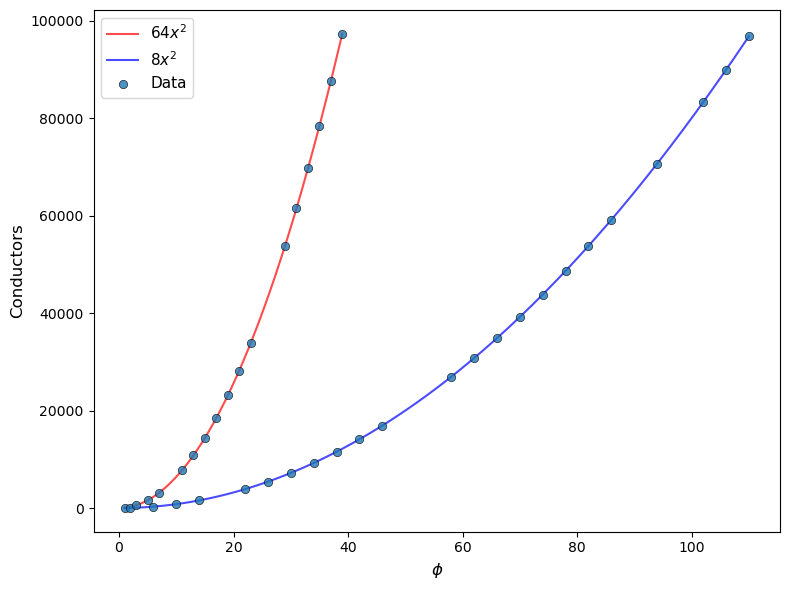

In [35]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: 64*x**2
g = lambda x: 8*x**2

# Plot
x_fit_f = np.linspace(min(phi_reps), max(phis_up), 200)
x_fit_g = np.linspace(min(phi_reps), max(phi_reps), 200)

plt.figure(figsize=(8, 6))
plt.plot(x_fit_f, f(x_fit_f), 'r-', label=r'$64x^2$', linewidth=1.5, alpha=0.7)
plt.plot(x_fit_g, g(x_fit_g), 'b-', label=r'$8x^2$', linewidth=1.5, alpha=0.7)
plt.scatter(phi_reps, cs, label='Data', alpha=0.8, edgecolors='k', linewidths=0.5, zorder=5)

plt.xlabel(r'$\phi$', fontsize=12)
plt.ylabel('Conductors', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [81]:
phis_up
# All odd, as they should! See Deshpa et al.

[11, 13, 15, 17, 19, 21, 23, 29, 31, 33, 35, 37, 39]

In [36]:
phi_rep
# These are all square-free numbers!

[1,
 2,
 3,
 5,
 6,
 7,
 10,
 11,
 13,
 14,
 15,
 17,
 19,
 21,
 22,
 23,
 26,
 29,
 30,
 31,
 33,
 34,
 35,
 37,
 38,
 39,
 42,
 46,
 58,
 62,
 66,
 70,
 74,
 78,
 82,
 86,
 94,
 102,
 106,
 110]

In [82]:
len(phi_reps)

40